In [1]:
include("../Interpolation.jl")
using .Interpolation
using StatsKit, Pipe, CairoMakie, LinearAlgebra, SwarmMakie
Makie.convert_arguments(::Type{<:AbstractPlot}, x::DataFrame) = ([Point2f(i) for i in Matrix(select(x, [:x, :y])) |> eachrow],)
Makie.convert_arguments(::Type{<:AbstractPlot}, df::DataFrame, col::Vector{Symbol}) = 
    (map(Point2f, select(df, col) |> Matrix |> eachrow),)

Base.rad2deg(x::Missing) = missing

In [ ]:
function read2dfs(subj, p2csvs)
    dfs = []
    for csv in p2csvs[subj]
        df = CSV.read(csv, DataFrame)
        push!(dfs, df)
    end
    return dfs
end

read2dfs (generic function with 1 method)

In [3]:
subjs = []
p2csvs = Dict{String, Vector{String}}()
for (root, dir, files) in walkdir("../final_results")
    if occursin("csvs", root)
        push!(subjs, split(root, "/")[end-1])
        push!(p2csvs, split(root, "/")[end-1] => [joinpath(root,f) for f in files if occursin(".csv", f)])
    end
end
# p2csvs

In [4]:
ori_df = read2dfs(subjs[5], p2csvs)[8]
println("Missing Frames num: ", cal_missing(ori_df))
interpolation_df = interpolation_missing_frame(ori_df)
new_merge_df = @pipe ori_df |> filter(:frames => x -> (x > 300) && (x%20 == 1)) |>
    vcat(_,interpolation_df) |> sort(_,:frames) 

@pipe new_merge_df |> 
    transform!(_, [:x,:y] => ((x,y) -> @pipe ([[missing;diff(x)]  [missing;diff(y)]] |> eachrow )) => :velocity) |> 
    transform!(_, :velocity => ByRow(norm) => :speed) 

new_merge_df[!, :angle_deg] = @pipe sum((@pipe new_merge_df.velocity[1:end-1]|>hcat(_...)') .* (@pipe new_merge_df.velocity[2:end]|>hcat(_...)'),dims=2) ./
    (new_merge_df.speed[1:end-1] .* new_merge_df.speed[2:end]) |>
    acosd.(_) |> 
    [missing; _] |> vec;

Missing Frames num: 0


In [5]:
after_cal_df = Dict{String, Vector{DataFrame}}()

Threads.@threads for subj in subjs
    all_dfs = read2dfs(subj, p2csvs)
    tmp_dfs = []
    for df in all_dfs
        # println(df)
        interpolation_df = interpolation_missing_frame(df)
    new_merge_df = @pipe df |> filter(:frames => x -> (x > 300) && (x%20 == 1)) |>
        vcat(_,interpolation_df) |> sort(_,:frames) 

    @pipe new_merge_df |> 
        transform!(_, [:x,:y] => ((x,y) -> @pipe ([[missing;diff(x)]  [missing;diff(y)]] |> eachrow )) => :velocity) |> 
        transform!(_, :velocity => ByRow(norm) => :speed) 

    tmp_cos =  @pipe sum((@pipe new_merge_df.velocity[1:end-1]|>hcat(_...)') .* (@pipe new_merge_df.velocity[2:end]|>hcat(_...)'),dims=2) ./
        (new_merge_df.speed[1:end-1] .* new_merge_df.speed[2:end])

        
    new_merge_df[!, :angle_deg] = acosd.([missing; [(ismissing(i)) ? missing : i > 1 ? i ≈ 1 ? 1 : missing : i for i in tmp_cos]] |> vec)
    # print(angle_deg_df)


    push!(tmp_dfs, new_merge_df)
    end
    after_cal_df[subj] = tmp_dfs
end

In [ ]:
subjs_type_df = CSV.File("../subjs_type.csv") |> DataFrame;

In [175]:
new_df = DataFrame(:data => String[], :dfs => DataFrame[])

for (subj, dfs) in after_cal_df
    for df in dfs
        push!(new_df, (subj, df))
    end
end
trained_frame = @pipe new_df |> filter(:data => x -> occursin("train", x)) |> 
    transform!(_, :dfs => ByRow(x -> size(x,1)) => :num_frame) |> 
    sort(_.:num_frame);
naive_frame = @pipe new_df |> filter(:data => x -> occursin("naive", x)) |> 
    transform!(_, :dfs => ByRow(x -> size(x,1)) => :num_frame) |> 
    sort(_.:num_frame);

In [176]:
subjs_type_df

Row,type,subjs
,String7,String31
1,naive,n2_naive2_3.14
2,naive,n2_naive3_3.14
3,naive,n2_naive1_3.16
4,naive,n2_naive4_3.16
5,naive,n2_naive4_3.17
6,naive,n2_naive5_3.17
7,naive,n2_naive6_3.17
8,naive,n2_naive10_3.18
9,naive,n2_naive8_3.18


In [177]:
leftjoin!(new_df, subjs_type_df, on=[:data => :subjs])

Row,data,dfs,type
,String,DataFrame,String7?
1,n2_naive4_3.19,164×10 DataFrame,naive
2,n2_naive4_3.19,294×9 DataFrame,naive
3,n2_naive4_3.19,193×9 DataFrame,naive
4,n2_naive4_3.19,253×9 DataFrame,naive
5,n2_naive4_3.19,424×9 DataFrame,naive
6,n2_naive4_3.19,344×9 DataFrame,naive
7,n2_naive4_3.19,418×9 DataFrame,naive
8,n2_naive4_3.19,661×9 DataFrame,naive
9,n2_naive4_3.17,408×9 DataFrame,naive


In [140]:
@pipe new_df |> 
    transform!(_, :dfs => ByRow(x -> ismissing.(x.angle_deg) |> sum) => :num_missing) |> sort(_,:num_missing, rev=true) 

Row,data,dfs,num_missing
,String,DataFrame,Int64
1,n2_naive4_3.19,164×10 DataFrame,2
2,n2_naive4_3.19,294×9 DataFrame,2
3,n2_naive4_3.19,193×9 DataFrame,2
4,n2_naive4_3.19,253×9 DataFrame,2
5,n2_naive4_3.19,424×9 DataFrame,2
6,n2_naive4_3.19,344×9 DataFrame,2
7,n2_naive4_3.19,418×9 DataFrame,2
8,n2_naive4_3.19,661×9 DataFrame,2
9,n2_naive4_3.17,408×9 DataFrame,2


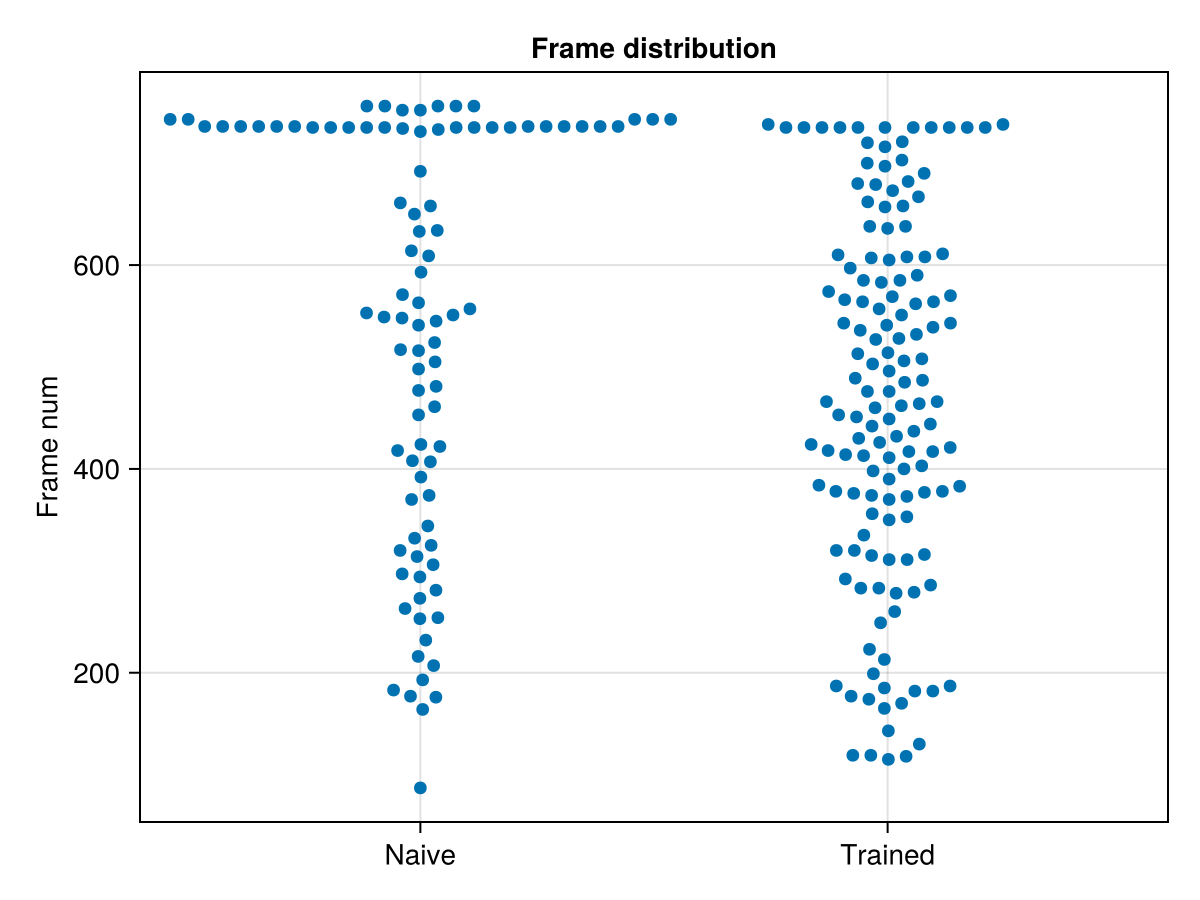

In [92]:
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Frame distribution",
    xticks = ([0,1], ["Naive", "Trained"]),
    ylabel = "Frame num")
beeswarm!(ax,[zeros(length(naive_frame)); ones(length(trained_frame))], [naive_frame; trained_frame] )
fig

In [174]:
trained_speed = @pipe new_df |> filter(:data => x -> occursin("train", x)) |> 
    transform!(_, :dfs => ByRow(x -> x.speed|> skipmissing |> collect |> mean) => :mean_speed) |> 
    sort(_.:mean_speed) 
naive_speed = @pipe new_df |> filter(:data => x -> occursin("naive", x)) |> 
    transform!(_, :dfs => ByRow(x -> x.speed|> skipmissing |> collect |> mean) => :mean_speed) |> 
    sort(_.:mean_speed) 

93-element Vector{Float64}:
  7.564164139079578
  7.577598708980363
  7.578809278555688
  7.663333832314437
  8.199416758713706
  8.380983173816048
  8.403897672700163
  8.43958506872699
  8.454026997225114
  8.636527375256872
  ⋮
 12.262658727371196
 12.494469715349762
 12.550388173918025
 12.656811427768705
 12.804059461691878
 13.17068344828687
 13.26981403872326
 13.296448293876761
 14.015940418510992

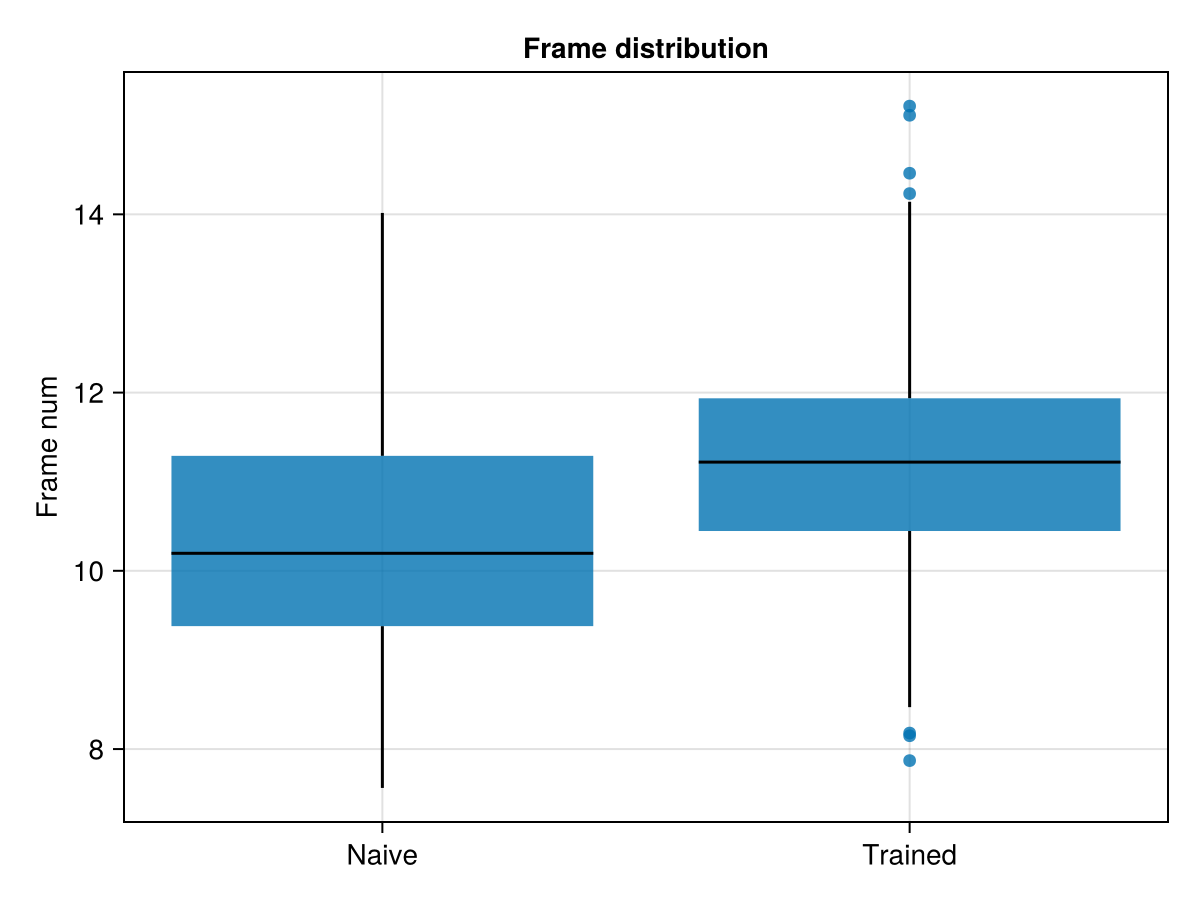

In [93]:
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Frame distribution",
    xticks = ([0,1], ["Naive", "Trained"]),
    ylabel = "Frame num")
boxplot!(ax,[zeros(length(naive_frame)); ones(length(trained_frame))], [naive_speed; trained_speed] )
fig

In [31]:
using KernelDensity

In [178]:
all_angle = @pipe vcat(new_df.dfs...).angle_deg |> skipmissing |> collect;
U = kde(all_angle)
x = collect(0:1e-3:180)
y = pdf(U, x)
threshold = x[argmin(y)]
# pdf(U, 0:1e-3:180) |> minimum

ArgumentError: ArgumentError: column(s) reorientation are missing from argument(s) 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206

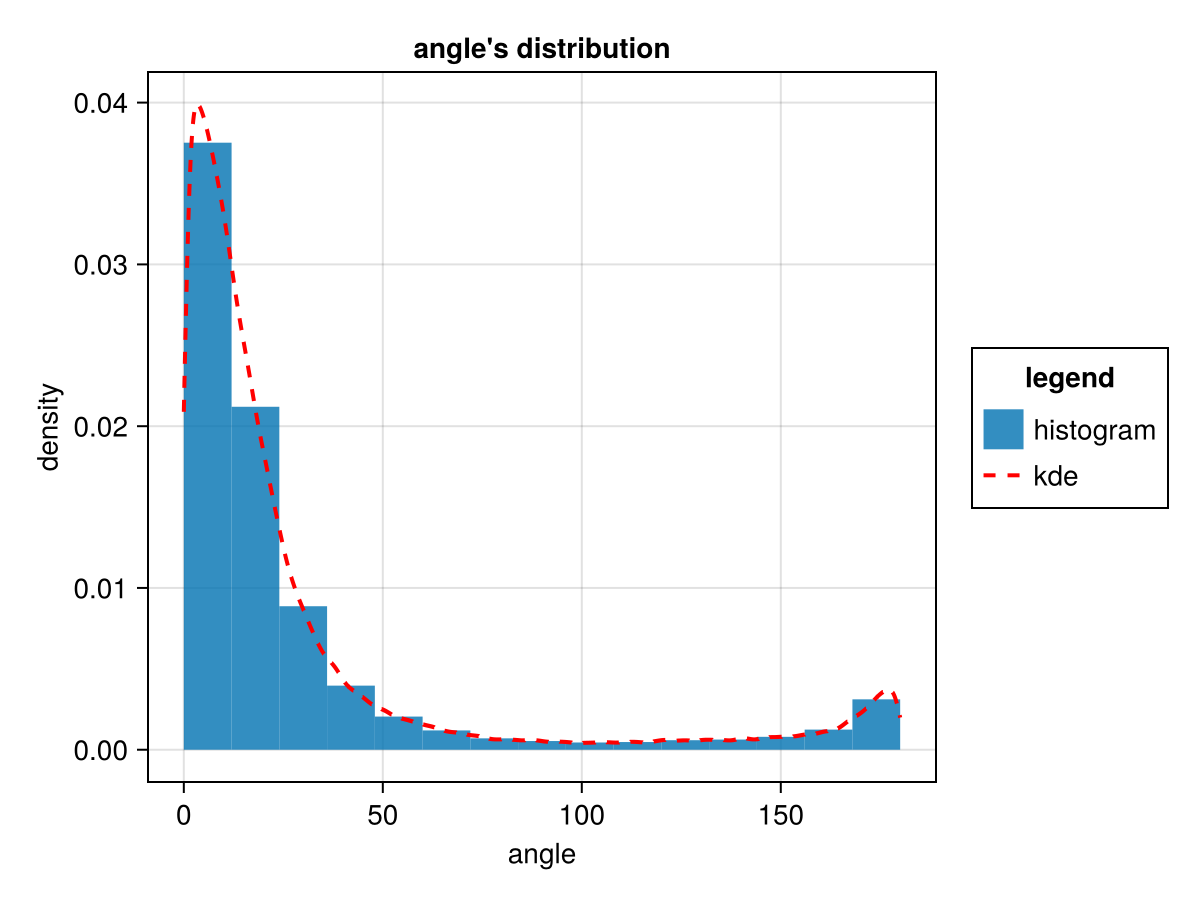

In [95]:
fig = Figure()
ax = Axis(fig[1,1], title="angle's distribution", xlabel="angle", ylabel="density")
hist!(ax, all_angle, normalization=:pdf, label="histogram")
lines!(ax, x, y,  color=:red, linewidth=2, label="kde", linestyle=:dash)
fig[1,2] = Legend(fig, ax, "legend")
fig

In [115]:
trained_dfs = @pipe new_df |> filter(:data => x -> occursin("train", x)) |> 
    vcat(_.dfs...);
naive_dfs = @pipe new_df |> filter(:data => x -> occursin("naive", x)) |> 
    vcat(_.dfs...);

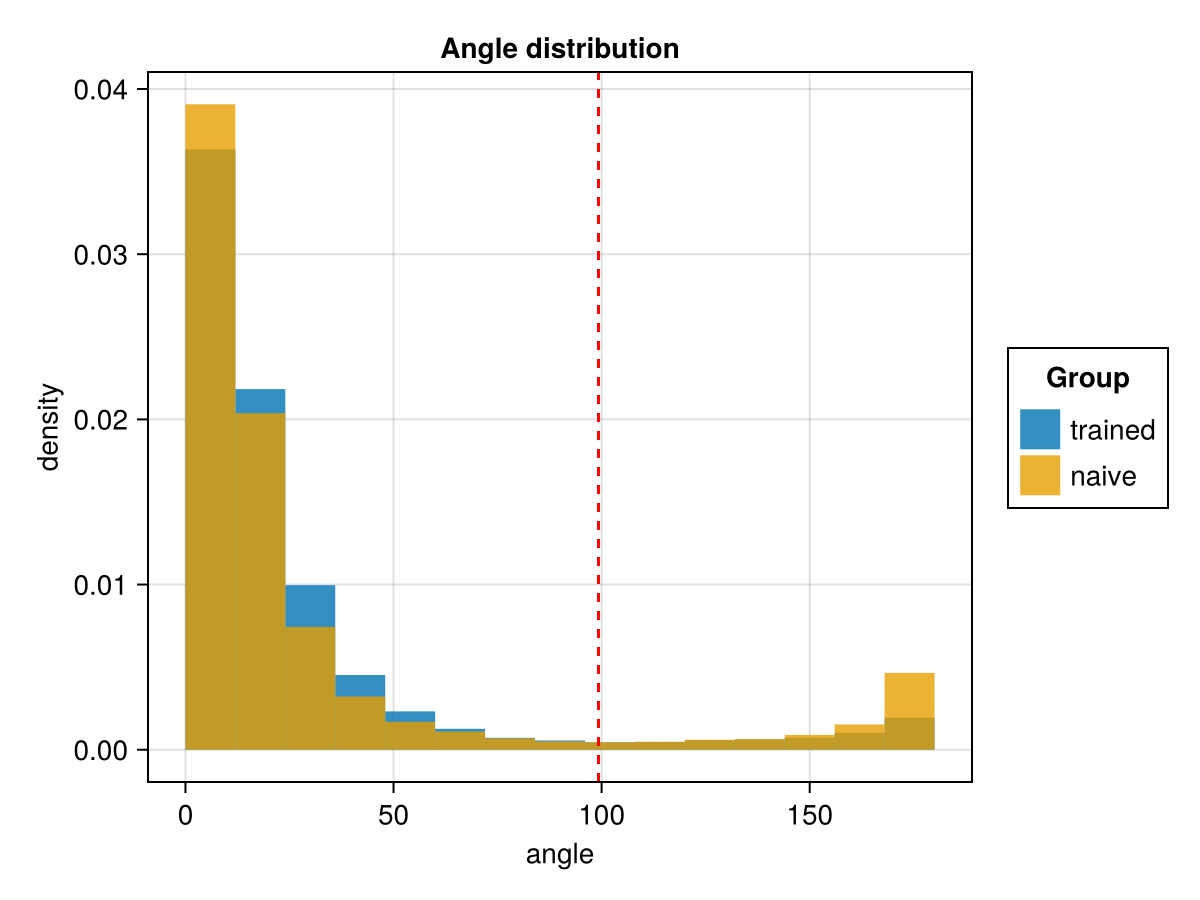

In [145]:
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Angle distribution", xlabel="angle", ylabel="density")
    # xticks = ([0,1], ["Naive", "Trained"]),
    # ylabel = "Frame num")
@pipe trained_dfs.angle_deg |> skipmissing |> collect  |> hist!(ax,_, normalization=:pdf, label="trained")
@pipe naive_dfs.angle_deg |> skipmissing |> collect  |> hist!(ax,_, normalization=:pdf, label="naive")
vlines!(ax, threshold, color=:red, linestyle=:dash)
fig[1,2] = Legend(fig, ax, "Group")
fig

In [165]:
gb_type = @pipe leftjoin(new_df, subjs_type_df, on=[:data => :subjs]) |>
    groupby(_, :type) |>
    combine(_, :dfs => (x -> x) => :all_dfs)

Row,type,all_dfs
,String7?,DataFrame
1,naive,164×10 DataFrame
2,naive,294×9 DataFrame
3,naive,193×9 DataFrame
4,naive,253×9 DataFrame
5,naive,424×9 DataFrame
6,naive,344×9 DataFrame
7,naive,418×9 DataFrame
8,naive,661×9 DataFrame
9,naive,408×9 DataFrame


In [161]:
gb_type[1,:dfs]

ArgumentError: ArgumentError: column name :dfs not found in the data frame

In [146]:
subjs

34-element Vector{Any}:
 "n2_naive10_3.18"
 "n2_naive1_3.16"
 "n2_naive2_3.14"
 "n2_naive3_3.14"
 "n2_naive4_3.16"
 "n2_naive4_3.17"
 "n2_naive4_3.19"
 "n2_naive5_3.17"
 "n2_naive5_3.19"
 "n2_naive6_3.17"
 ⋮
 "n2_trained5_3.18"
 "n2_trained6_3.18"
 "n2_trained7_3.17"
 "n2_trained7_3.18"
 "n2_trained7_3.19"
 "n2_trained8_3.17"
 "n2_trained8_3.19"
 "n2_trained9_3.17"
 "n2_trained9_3.19"

2

In [ ]:
@pipe new_df[1,:dfs] |> 
    transform!(_, :angle_deg => ByRow(x -> ismissing(x) ? missing : (x > threshold) ? 1 : 0) => :reorientation) |> 

Row,frames,trackers_id,x,y,width,height,velocity,speed,angle_deg,reorientation
,Any,Any,Any,Any,Any,Any,SubArray…,Float64?,Float64?,Int64?
1,301,21,1674.04,1231.78,5.67267,18.4921,"Union{Missing, Float64}[missing, missing]",missing,missing,missing
2,321,21,1667.26,1232.9,6.90278,9.9713,"Union{Missing, Float64}[-6.78538, 1.12222]",6.87755,missing,missing
3,341,21,1661.93,1243.33,8.32347,14.9712,"Union{Missing, Float64}[-5.33074, 10.4333]",11.7163,53.5449,0
4,361,21,1656.43,1257.03,7.347,16.0706,"Union{Missing, Float64}[-5.49495, 13.7003]",14.7612,5.20922,0
5,381,21,1652.18,1269.31,5.37497,18.5576,"Union{Missing, Float64}[-4.25589, 12.2727]",12.9897,2.72946,0
6,401,21,1656.81,1279.77,9.55482,14.3371,"Union{Missing, Float64}[4.63488, 10.4631]",11.4437,43.0175,0
7,421,21,1656.57,1278.74,6.93599,16.9518,"Union{Missing, Float64}[-0.243626, -1.02837]",1.05683,169.436,1
8,441,21,1655.7,1279.7,6.09374,16.5179,"Union{Missing, Float64}[-0.86793, 0.960487]",1.29454,124.57,1
9,461,21,1649.56,1269.55,6.79376,16.8862,"Union{Missing, Float64}[-6.14286, -10.1528]",11.8665,106.722,1


DimensionMismatch: DimensionMismatch: column :n2_naive4_3.19 has length 8 and column :n2_naive4_3.17 has length 9

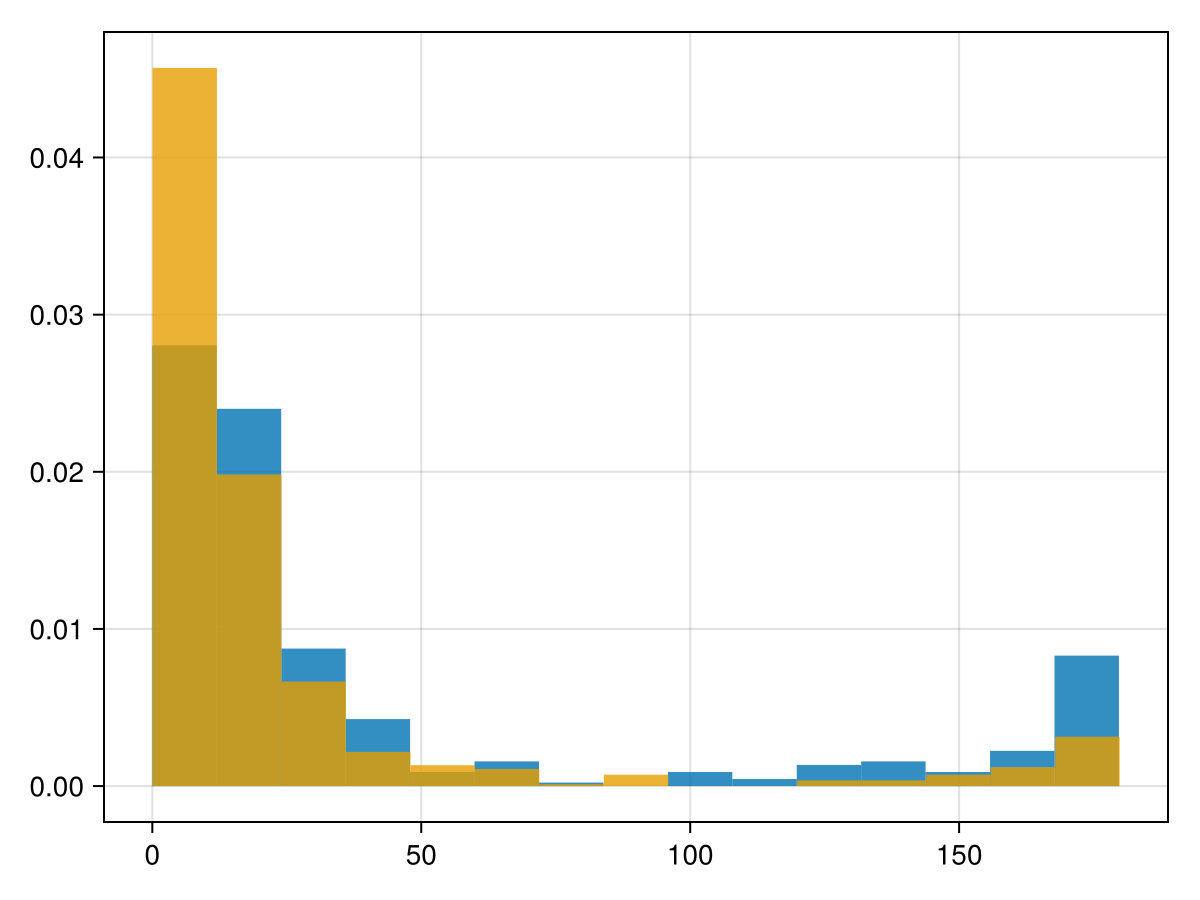

In [11]:
fig = Figure()
ax = Axis(fig[1,1])
@pipe after_cal_df[subjs[1]][1] |> _.angle_deg |> skipmissing |> collect |> hist!(ax, _, normalization=:pdf)
@pipe after_cal_df[subjs[4]][1] |> _.angle_deg |> skipmissing |> collect |> hist!(ax, _, normalization=:pdf)
fig

In [12]:
acosdInf 

UndefVarError: UndefVarError: `acosdInf` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [13]:
t_df = read2dfs("n2_naive3_3.14", p2csvs)[2]

interpolation_df = interpolation_missing_frame(t_df)
new_merge_df = @pipe t_df |> filter(:frames => x -> (x > 300) && (x%20 == 1)) |>
    vcat(_,interpolation_df) |> sort(_,:frames) 

@pipe new_merge_df |> 
    transform!(_, [:x,:y] => ((x,y) -> @pipe ([[missing;diff(x)]  [missing;diff(y)]] |> eachrow )) => :velocity) |> 
    transform!(_, :velocity => ByRow(norm) => :speed) 

# @show subj

tmp_cos = @pipe sum((@pipe new_merge_df.velocity[1:end-1]|>hcat(_...)') .* (@pipe new_merge_df.velocity[2:end]|>hcat(_...)'),dims=2) ./
    (new_merge_df.speed[1:end-1] .* new_merge_df.speed[2:end])  |> skipmissing |> maximum
    # acosd.(_) |> 
    # [missing; _] |> vec;

# new_merge_df

1.0000000000000002

In [15]:
new_merge_df

Row,frames,trackers_id,x,y,width,height,velocity,speed
,Int64,Float64?,Float64?,Float64?,Float64?,Float64?,SubArray…,Float64?
1,301,15.0,1530.32,1125.14,5.63297,20.6091,"Union{Missing, Float64}[missing, missing]",missing
2,321,15.0,1530.88,1107.53,7.063,17.2063,"Union{Missing, Float64}[0.558838, -17.6037]",17.6126
3,341,16.0,1529.49,1081.82,7.43179,38.7881,"Union{Missing, Float64}[-1.39289, -25.7113]",25.749
4,361,16.0,1528.39,1070.88,7.84952,25.9948,"Union{Missing, Float64}[-1.09592, -10.9454]",11.0001
5,381,16.0,1528.97,1061.56,9.69524,22.3666,"Union{Missing, Float64}[0.57484, -9.31604]",9.33376
6,401,16.0,1529.66,1054.81,9.05451,23.113,"Union{Missing, Float64}[0.696928, -6.75529]",6.79115
7,421,16.0,1530.67,1047.59,10.9304,21.0195,"Union{Missing, Float64}[1.00427, -7.22041]",7.28992
8,441,16.0,1531.36,1041.09,7.04309,26.1266,"Union{Missing, Float64}[0.692542, -6.49453]",6.53135
9,461,16.0,1534.14,1033.22,9.09481,19.6391,"Union{Missing, Float64}[2.78452, -7.8742]",8.35204


In [16]:
acosd()

MethodError: MethodError: no method matching acosd()
The function `acosd` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  acosd(!Matched::BigFloat)
   @ Base mpfr.jl:887
  acosd(!Matched::ColorTypes.AbstractGray)
   @ ColorVectorSpace ~/.julia/packages/ColorVectorSpace/tLy1N/src/ColorVectorSpace.jl:303
  acosd(!Matched::ForwardDiff.Dual{T}) where T
   @ ForwardDiff ~/.julia/packages/ForwardDiff/UBbGT/src/dual.jl:242
  ...


In [18]:
cos(missing)

missing

In [19]:
subjs[5]

"n2_naive4_3.16"

In [20]:
acosd(missing)

missing

In [21]:
Base.rad2deg(x::Missing) = missing

In [22]:
new_merge_df.velocity[4]' * new_merge_df.velocity[3] / (norm(new_merge_df.velocity[4]) * norm(new_merge_df.velocity[3])) |> acosd

2.6168194890419145

In [24]:
skipmissing(new_merge_df.speed) |> collect

733-element Vector{Float64}:
 17.612593336392578
 25.748999339592437
 11.000105321666979
  9.333760837993577
  6.7911487934706525
  7.289915951611298
  6.531354461429003
  8.352039979975977
  7.617618036049149
  9.532679219812785
  ⋮
  3.061979645458033
  4.498368099489452
 16.121121579391488
 16.56788900600782
 16.756614181087084
 16.166927087582078
 16.78435050109523
 13.909707536799836
 14.095761766999836

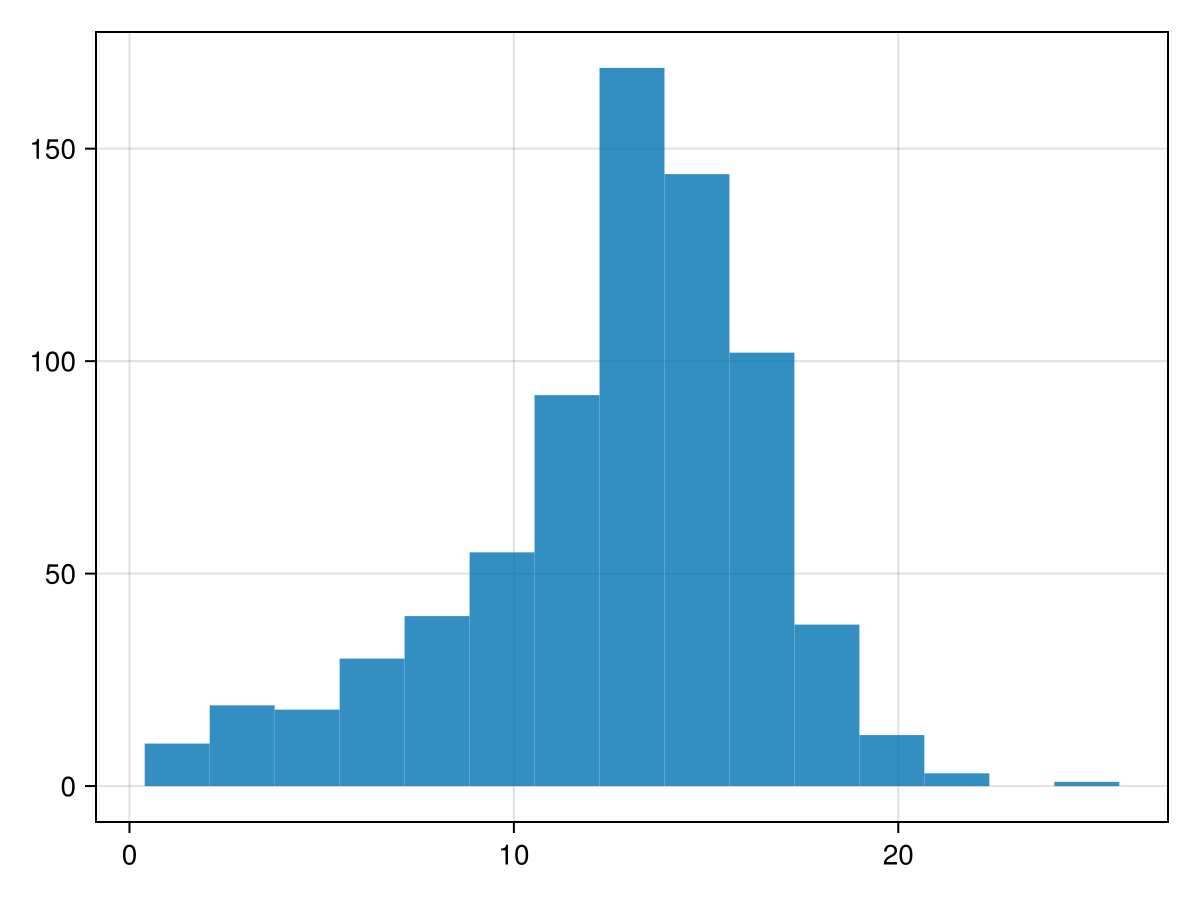

In [25]:
hist(new_merge_df.speed |> skipmissing |> collect )

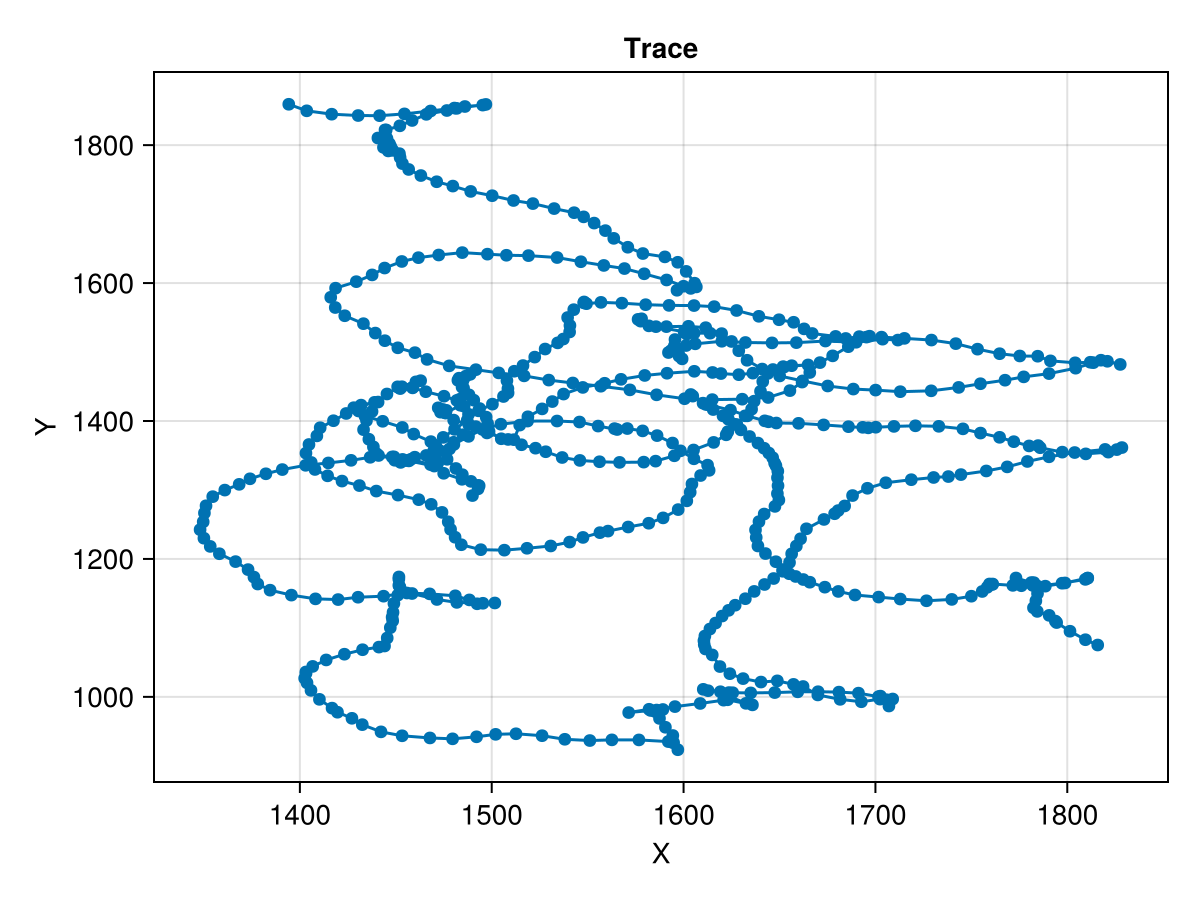

In [26]:
vis_trace(ori_df)